In [171]:
%load_ext autoreload
%autoreload 2
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import numpy as np
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
from scipy.stats import norm
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d

# Function to find the project root directory
for parent in [Path.cwd().resolve()] + list(Path.cwd().resolve().parents):
    if (parent / "utils").exists():
        sys.path.insert(0, str(parent))
        break

from utils.pathing import setup_repo_path
ROOT = setup_repo_path()
print(f"Project root set to: {ROOT}")
# -----------------------------------------------

from limit_states import REGISTRY as ls_REGISTRY

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Project root set to: D:\active_train\acquisition\MOO-AL


In [172]:
def compute_pareto_intervals(xx, yy, target=None, res=100_001):
    F = np.column_stack([xx, yy])
    z_star = F.max(axis=0)
    W = np.linspace(0, 1, res)
    
    dev = np.abs(F - z_star) 
    T = np.sqrt((W[None,:] * dev[:,[0]])**2 + ((1 - W)[None,:] * dev[:,[1]])**2)
    best = np.argmin(T, axis=0)

    # 1) build intervals for all “winning” Pareto indices
    intervals = {}
    curr = best[0]
    start = 0
    for j in range(1, len(W)):
        if best[j] != curr:
            intervals.setdefault(curr, []).append((W[start], W[j-1]))
            curr = best[j]
            start = j
    intervals.setdefault(curr, []).append((W[start], W[-1]))

    # no target? just return the full dict
    if target is None:
        return intervals

    # 2) locate the target’s index in F by finding the NEAREST point (FIX 1)
    target_point = np.array(target)
    distances_sq = np.sum((F - target_point)**2, axis=1)
    idx = np.argmin(distances_sq)
    
    TOLERANCE = 1e-3
    if np.sqrt(distances_sq[idx]) > TOLERANCE:
        return None, None 

    # 3) if it already *wins* somewhere, just return its intervals
    if idx in intervals:
        return idx, intervals[idx]

    # 4) otherwise we need to find the nearest Pareto points *with* intervals
    order = np.argsort(F[:,0])  # sort by x (or pick y if you prefer)
    pos   = np.where(order == idx)[0][0]

    # scan left
    lower_idx = None
    for i in range(pos-1, -1, -1):
        cand = order[i]
        if cand in intervals:
            lower_idx = cand
            break

    # scan right
    upper_idx = None
    for i in range(pos+1, len(order)):
        cand = order[i]
        if cand in intervals:
            upper_idx = cand
            break

    # --- NEW EDGE CASE FIX (FIX 2) ---
    
    # Check if we are at the rightmost point (F[idx] has max f1)
    is_rightmost = (idx == order[-1])
    
    # Check if we are at the leftmost point (F[idx] has min f1)
    is_leftmost = (idx == order[0])

    if is_rightmost and lower_idx is not None:
        # If the target point is the rightmost point, its upper bound is W_max=1
        low_bound  = max(end for (_, end) in intervals[lower_idx])
        high_bound = 1.0 # Force the upper bound to the max possible weight
        return idx, [(low_bound, high_bound)]

    if is_leftmost and upper_idx is not None:
        # If the target point is the leftmost point, its lower bound is W_min=0
        low_bound  = 0.0 # Force the lower bound to the min possible weight
        high_bound = min(start for (start, _) in intervals[upper_idx])
        return idx, [(low_bound, high_bound)]

    # --- END NEW EDGE CASE FIX ---

    # If we didn’t find both sides AND it's not an edge case, we can’t form an interval
    if lower_idx is None or upper_idx is None:
        return idx, None

    # 5) splice their boundaries: (Original Logic)
    low_bound  = max(end for (_, end) in intervals[lower_idx])
    high_bound = min(start for (start, _) in intervals[upper_idx])

    return idx, [(low_bound, high_bound)]

In [ ]:
# def compute_pareto_intervals(xx, yy, target=None, res=100_001):
#     F = np.column_stack([xx, yy])
#     z_star = F.max(axis=0)
#     W = np.linspace(0, 1, res)
#     dev = np.abs(F - z_star)
#     T = np.sqrt((W[None,:] * dev[:,[0]])**2 + ((1 - W)[None,:] * dev[:,[1]])**2)
#     best = np.argmin(T, axis=0)

#     # 1) build intervals for all “winning” Pareto indices
#     intervals = {}
#     curr = best[0]
#     start = 0
#     for j in range(1, len(W)):
#         if best[j] != curr:
#             intervals.setdefault(curr, []).append((W[start], W[j-1]))
#             curr = best[j]
#             start = j
#     intervals.setdefault(curr, []).append((W[start], W[-1]))

#     # no target?  just return the full dict
#     if target is None:
#         return intervals

#     # 2) locate the target’s index in F
#     idx = None
#     for i, (x,y) in enumerate(F):
#         if np.isclose(x, target[0]) and np.isclose(y, target[1]):
#             idx = i
#             break
#     if idx is None:
#         return None, None

#     # 3) if it already *wins* somewhere, just return its intervals
#     if idx in intervals:
#         return idx, intervals[idx]

#     # 4) otherwise we need to find the nearest Pareto points *with* intervals
#     order = np.argsort(F[:,0])  # sort by x (or pick y if you prefer)
#     pos   = np.where(order == idx)[0][0]

#     # scan left
#     lower_idx = None
#     for i in range(pos-1, -1, -1):
#         cand = order[i]
#         if cand in intervals:
#             lower_idx = cand
#             break

#     # scan right
#     upper_idx = None
#     for i in range(pos+1, len(order)):
#         cand = order[i]
#         if cand in intervals:
#             upper_idx = cand
#             break

#     # if we didn’t find both sides, we still can’t form an interval
#     if lower_idx is None or upper_idx is None:
#         return idx, None

#     # 5) splice their boundaries:
#     #    lower bound = the *furthest* right end of the lower neighbour
#     low_bound  = max(end for (_, end) in intervals[lower_idx])
#     #    upper bound = the *furthest* left start of the upper neighbour
#     high_bound = min(start for (start, _) in intervals[upper_idx])

#     return idx, [(low_bound, high_bound)]

In [ ]:
# case_it = 'four_branch_6'
# exp_it = 'mook_vs_u_eff'
# it = 129
# Pareto = np.array(data_by_case[case_it][exp_it]['Pareto_metrics'][it][0])
# # assume you pick the first (or only) selected sample per iter:
# xs, ys = data_by_case[case_it][exp_it]['Pareto_metrics'][it][1][0]
# sel_idx, sel_interval = compute_pareto_intervals(Pareto[:,0],
#                                             Pareto[:,1],
#                                             target=[xs, ys],
#                                             res=100_001)
# sel_idx, sel_interval

In [ ]:
# def load_output_data_from_name_exp(name_exp, case_study, base='results_acquisition_comparison'):
#     # Extract al_strategy from the first word before '_'
#     al_strategy = name_exp.split('_')[0]

#     config = {}
#     if al_strategy == 'moor':
#         al_strategy = 'moo'
#         config['moo_method'] = 'reliability'
#         # print(config)
#     elif al_strategy == 'mook':
#         al_strategy = 'moo'
#         config['moo_method'] = 'knee'
#     elif al_strategy == 'mooc':
#         al_strategy = 'moo'
#         config['moo_method'] = 'compromise'

#     print(f"Loading data for case study: {case_study}, AL strategy: {al_strategy}, Experiment name: {name_exp}")
#     config['case_study'] = case_study
#     config['passive_samples'] = 10
#     config['al_batch'] = 1
#     config['al_strategy'] = al_strategy
#     # # Add moo_method if needed
#     # if config['al_strategy'] == 'moo':
#     #     config['moo_method'] = 'reliability'

#     script_folder = os.getcwd()
#     base_results_dir = os.path.join(script_folder, base)
    
#     # print(config)
#     if config['al_strategy'] == 'moo':
#         dir_pattern = os.path.join(
#             base_results_dir,
#             config['case_study'],
#             f"{config['al_strategy']}_{config['moo_method']}_{config['al_batch']}_{name_exp}_*"
#         )
#     else:
#         dir_pattern = os.path.join(
#             base_results_dir,
#             config['case_study'],
#             f"{config['al_strategy']}_{config['al_batch']}_{name_exp}_*"
#         )
#     matching_dirs = glob.glob(dir_pattern)
#     output_json_path = os.path.join(matching_dirs[0], 'output.json')

#     if os.path.isfile(output_json_path):
#         with open(output_json_path, 'r') as f:
#             output_data = json.load(f)
#         return output_data
#     else:
#         raise FileNotFoundError(f"{output_json_path} not found.")

In [173]:
import os
import glob
import json

def load_output_data_from_name_exp(name_exp, case_study, base='results_revision_weights'):
    """
    Loads all output.json files for a given case study, adapting the search pattern
    based on the case_study name.

    name_exp: The experiment number (e.g., '1'), which is ignored for 'nonlinear_oscillator'.
    case_study: The name of the case study (e.g., 'four_branch_6').
    """
    
    exp_num = str(name_exp)
    experiment_data = {} 

    script_folder = os.getcwd()
    base_results_dir = os.path.join(script_folder, base)
    
    # --- Conditional Directory Pattern Creation ---
    if case_study == 'nonlinear_oscillator':
        # Search for ALL experiment numbers ('*') and ALL batches/strategies
        # Pattern: {base_results_dir}/{case_study}/*_*_*_*
        # Note: The third '*' now replaces exp_num (e.g., '1'), making it wildcarded.
        dir_pattern = os.path.join(
            base_results_dir,
            case_study,
            f"*_*_*_*"  # Matches 'strategy_batch_exp_num_timestamp' where exp_num is a wildcard
        )
    else:
        # Search only for the specified experiment number (e.g., '1')
        # Pattern: {base_results_dir}/{case_study}/*_*_{exp_num}_*
        dir_pattern = os.path.join(
            base_results_dir,
            case_study,
            f"*_*_{exp_num}_*"  # Matches 'strategy_batch_exp_num_timestamp' where exp_num is fixed
        )
    
    print(f"Searching pattern for {case_study}, Exp {exp_num}: {dir_pattern}")
    
    matching_dirs = glob.glob(dir_pattern)

    if not matching_dirs:
        print(f"No directories found for case: {case_study}.")
        return experiment_data # Return empty dict if nothing found

    # --- Data Loading Logic (Remains the same) ---
    for dir_path in matching_dirs:
        dir_name = os.path.basename(dir_path)
        parts = dir_name.split('_')
        
        # Determine the strategy key (everything before the batch size '1')
        strategy_key_parts = []
        for part in parts:
            # Assuming the batch size (which separates strategy from exp_num/timestamp) is '1'
            if part == '1': 
                break
            strategy_key_parts.append(part)
        
        # If the loop breaks early (found '1'), we use the parts collected. 
        # If not, it might mean the directory name is short, so use the first part.
        if not strategy_key_parts and parts:
             strategy_key = parts[0] # Fallback to the first element if '1' wasn't found immediately
        else:
             strategy_key = '_'.join(strategy_key_parts)
             
        # Handle the case where the strategy name itself is short (e.g., 'u', 'eff')
        if strategy_key in ['u', 'eff', 'portfolio'] and len(strategy_key_parts) == 1:
            pass # Keep the single part name

        # Handling potential ambiguity for the nonlinear_oscillator case (multiple exp_num are present)
        # We need to distinguish between experiments in the final dictionary structure.
        
        # Find the experiment number for this directory
        try:
            # Locate the experiment number in the parts list (it's the third element from the end of the strategy key)
            # The structure is assumed to be: Strategy_Batch_ExpNum_Timestamp...
            # The experiment number is the component immediately after the batch size '1'.
            
            # Since 'nonlinear_oscillator' searches for all experiments, we need to embed the exp_num
            # in the final key to avoid overwriting data from different experiments with the same strategy.
            
            # Reconstruct the experiment number based on its position after the strategy key parts
            exp_index_in_parts = len(strategy_key_parts) + 1 # Position of exp_num if batch size is one part
            
            if len(parts) > exp_index_in_parts:
                current_exp_num = parts[exp_index_in_parts]
            else:
                current_exp_num = 'unknown' # Fallback
            
        except (ValueError, IndexError):
            current_exp_num = 'unknown'

        # Create a unique key that includes the experiment number if it's not the fixed one
        final_key = strategy_key
        if case_study == 'nonlinear_oscillator':
             # For 'nonlinear_oscillator', data is grouped by strategy and experiment number
             final_key = f"{strategy_key}_{current_exp_num}"


        output_json_path = os.path.join(dir_path, 'output.json')

        if os.path.isfile(output_json_path):
            with open(output_json_path, 'r') as f:
                # Load the data and store it using the final key
                experiment_data[final_key] = json.load(f)
                print(f"   ✓ Loaded data for strategy: {final_key}")
        else:
            print(f"   ✗ Warning: No output.json found in {dir_path}")
            
    return experiment_data

In [174]:
import os
import glob
import json
import re # We'll need regex to reliably extract the experiment number

# Assuming the load_output_data_from_name_exp function from the last step is defined.

# --- Setup ---
# name_exp is now discovered automatically
case_study = ['four_branch_6', 'nonlinear_oscillator']
base_folder = 'results_revision_weights'

# Set up the base directory path
script_folder = os.getcwd()
base_results_dir = os.path.join(script_folder, base_folder)

# ── PHASE 1: LOAD ALL DATA ONCE ────────────────────────────────────
# Structure: data_by_case[case][exp][strategy] = {output_data}
data_by_case = {}

# Regex pattern to find the experiment number (assuming it's the third component 
# in the directory name, separated by underscores)
# Example dir: 'moo_reliability_1_5_2025_11_13_07_32_30' -> exp='5'
# The structure is assumed to be: {Strategy}_{Batch}_{ExpNum}_{Timestamp}
EXP_NUM_PATTERN = r'[^_]+_[^_]+_(\d+)_.*' # Matches anything_anything_(ExpNum)_anything

for case in case_study:
    print(f"\n--- Processing Case Study: {case} ---")
    data_by_case[case] = {}
    
    # 1. DISCOVER ALL EXPERIMENT NUMBERS FOR THIS CASE
    case_dir = os.path.join(base_results_dir, case)
    
    # Find all directories in the case folder
    all_case_dirs = glob.glob(os.path.join(case_dir, '*'))
    
    discovered_exp_names = set()
    
    for dir_path in all_case_dirs:
        if os.path.isdir(dir_path):
            dir_name = os.path.basename(dir_path)
            
            # Use regex to extract the experiment number
            match = re.match(EXP_NUM_PATTERN, dir_name)
            if match:
                # The first group (group 1) is the experiment number (\d+)
                exp_num = match.group(1) 
                discovered_exp_names.add(exp_num)

    # Sort the discovered experiment numbers numerically
    name_exp_discovered = sorted(list(discovered_exp_names), key=int)
    
    if not name_exp_discovered:
        print(f"No experiments found for case: {case}. Skipping.")
        continue
        
    print(f"Discovered experiment numbers for {case}: {name_exp_discovered}")

    # 2. ITERATE OVER DISCOVERED EXPERIMENTS AND LOAD DATA
    for exp in name_exp_discovered:
        # NOTE: The load_output_data_from_name_exp must be robust enough
        # to handle the two distinct behaviors you requested (fixed exp='1' vs. wildcard)
        # when called repeatedly inside this loop. The last provided version does this.
        
        all_strategies_data = load_output_data_from_name_exp(
            exp, case, base=base_folder
        )
        
        # Assign the dictionary of results to the current case/exp
        
        if case == 'nonlinear_oscillator':
            # In the last version, 'nonlinear_oscillator' loading was designed to get ALL
            # experiments in a single call, and keys were like 'strategy_expnum'.
            # To fix this conflict: When we iterate over a specific 'exp', we assume 
            # the load function only returns data relevant to that 'exp'.
            
            # --- REVERTING THE load_output_data_from_name_exp LOGIC FOR SIMPLICITY ---
            # If we iterate over 'exp' here, the load function should search *only* for that exp.
            
            # We assume a simplified load function where the search pattern is *always* # "*_*_{exp}_*" when called inside the loop.
            
            # If you are using the *last* complex version of load_output_data_from_name_exp,
            # you must *only* call it once for 'nonlinear_oscillator' outside the 'exp' loop.
            
            # --- OPTION A: STICKING TO SIMPLE ITERATION (EASIER) ---
            # If load_output_data_from_name_exp searches for *only* the passed 'exp':
            
            # This handles all strategies for the current 'exp'.
            data_by_case[case][exp] = all_strategies_data
            
        else:
            # This handles all strategies for the current 'exp'.
            data_by_case[case][exp] = all_strategies_data

# The loop is now independent of a predefined name_exp list.
# You will need to ensure your latest version of `load_output_data_from_name_exp`
# is available and handles the experiment number parameter correctly based on this structure.


--- Processing Case Study: four_branch_6 ---
Discovered experiment numbers for four_branch_6: ['1']
Searching pattern for four_branch_6, Exp 1: d:\active_train\acquisition\MOO-AL\notebooks\results_revision_weights\four_branch_6\*_*_1_*
   ✓ Loaded data for strategy: eff
   ✓ Loaded data for strategy: erf
   ✓ Loaded data for strategy: moo_compromise
   ✓ Loaded data for strategy: moo_eps_ew
   ✓ Loaded data for strategy: moo_knee
   ✓ Loaded data for strategy: moo_reliability
   ✓ Loaded data for strategy: portfolio
   ✓ Loaded data for strategy: reif
   ✓ Loaded data for strategy: u

--- Processing Case Study: nonlinear_oscillator ---
Discovered experiment numbers for nonlinear_oscillator: ['1']
Searching pattern for nonlinear_oscillator, Exp 1: d:\active_train\acquisition\MOO-AL\notebooks\results_revision_weights\nonlinear_oscillator\*_*_*_*
   ✓ Loaded data for strategy: eff_1
   ✓ Loaded data for strategy: erf_1
   ✓ Loaded data for strategy: moo_compromise_2
   ✓ Loaded data for 

In [175]:
case = 'nonlinear_oscillator'
strategies_data = data_by_case[case][exp]
out = strategies_data['moo_eps_ew_1']
idx = 15
Pareto = np.array(out['Pareto_metrics'][idx][0])
xs, ys = out['Pareto_metrics'][idx][1]
grid_resolution = 100_001

select_idx, sel_interval = compute_pareto_intervals(
Pareto[:, 0], # First objective
    Pareto[:, 1], # Second objective
    target=[-xs, ys],
    res=grid_resolution
            )
select_idx, sel_interval

(8, [(0.34, 0.74546)])

In [176]:
history = out['portfolio_history']

from collections import Counter

counts = Counter(history)
labels = list(counts.keys())
values = list(counts.values())

plt.figure(figsize=(6,4))
plt.bar(labels, values)
plt.title(f"{case} - Portfolio Participation")
plt.ylabel("Selections")
plt.xlabel("Acquisition Function")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.show()

KeyError: 'portfolio_history'

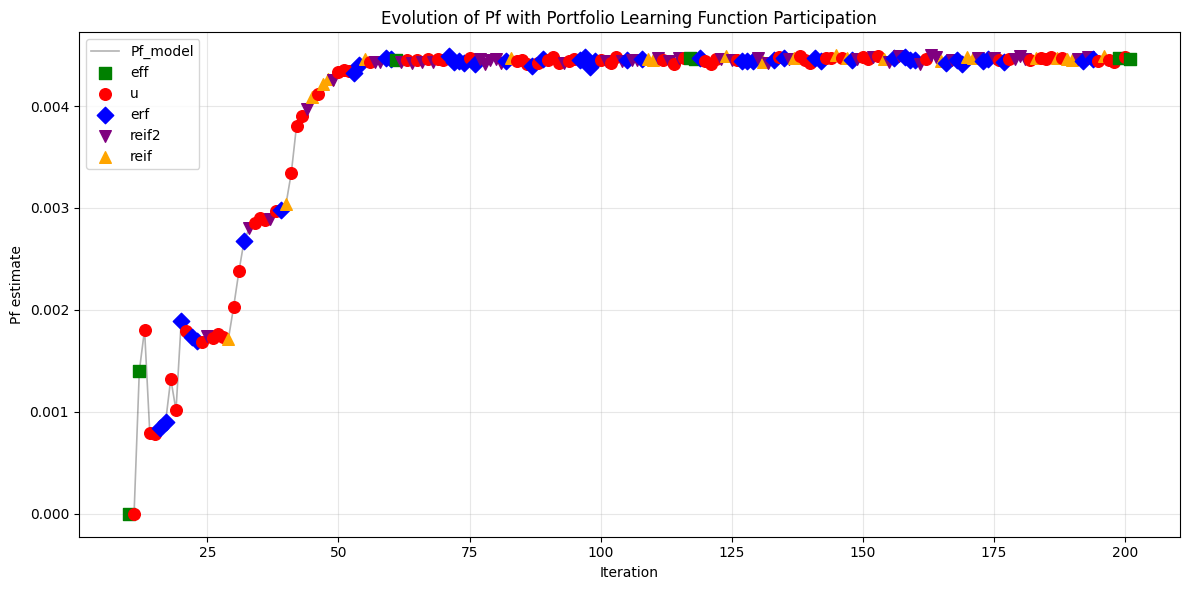

In [7]:
import numpy as np
import matplotlib.pyplot as plt

history = out['portfolio_history']
pf_model = np.asarray(out['Pf_model'])

start = 10
iterations = np.arange(start, start + len(pf_model))

# Map each learning function to a color + marker
lf_styles = {
    "u":     ("red",     "o"),
    "eff":   ("green",   "s"),
    "erf":   ("blue",    "D"),
    "reif":  ("orange",  "^"),
    "reif2": ("purple",  "v"),
}

plt.figure(figsize=(12, 6))

# Background Pf curve
plt.plot(iterations, pf_model, color="black", linewidth=1.2, alpha=0.3, label="Pf_model")

# --- automatic alignment between history and pf_model ---
len_hist = len(history)
len_pf   = len(pf_model)

# offset = index in pf_model corresponding to history[0]
offset = len_pf - len_hist
# common cases:
#  - offset == 0  -> history[k] ↔ pf_model[k]
#  - offset == 1  -> history[k] ↔ pf_model[k+1]

# Keep track of which labels we've already added to the legend
used_labels = set()

for i, lf in enumerate(history):
    idx = i + offset
    if not (0 <= idx < len_pf):
        # safety: skip any misaligned indices
        continue

    color, marker = lf_styles.get(lf, ("gray", "o"))
    label = lf if lf not in used_labels else ""
    used_labels.add(lf)

    plt.scatter(
        iterations[idx],
        pf_model[idx],
        color=color,
        marker=marker,
        s=70,
        label=label,
        zorder=3,
    )
# plt.xlim(10, 40)
plt.xlabel("Iteration")
plt.ylabel("Pf estimate")
plt.title("Evolution of Pf with Portfolio Learning Function Participation")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

In [8]:
# for idx in range(0, 190):
#     Pareto = np.array(out['Pareto_metrics'][idx][0])
#     xs, ys = out['Pareto_metrics'][idx][1]

#     _, sel_interval = compute_pareto_intervals(
#     Pareto[:, 0], # First objective
#         Pareto[:, 1], # Second objective
#         target=[-xs, ys],
#         res=grid_resolution
#                 )
    
#     print(f"IDX {idx}: W in [{sel_interval}]")

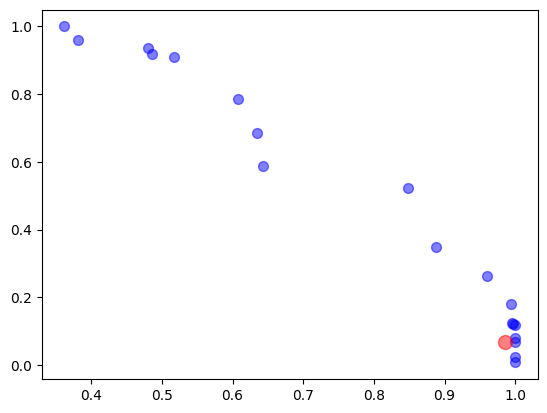

In [8]:
# Plot the first element
plt.scatter(Pareto[:, 0]+1, Pareto[:, 1], label='Pareto samples', s=50, color='blue', alpha=0.5)

# Plot the second element
plt.scatter(1-xs, ys, label='Selected sample', color='red', s=100, alpha=0.5)

In [26]:
import numpy as np
# Assuming compute_pareto_intervals is available in the current scope
# Assuming case_study and data_by_case are populated from the previous step

# ── 1) PRE‐COMPUTE ALL INTERVAL MEANS ───────────────────────────────
# The structure is: interval_mean[case][exp][strategy] = np.array(sel_intervals)
interval_mean = {}
grid_resolution = 100_001

for case in case_study:
    interval_mean[case] = {}
    
    # Iterate over all discovered experiment numbers (exp) loaded for this case
    # We use data_by_case[case].keys() to get all the 'exp' indices found.
    # Note: data_by_case[case] is a dictionary where keys are experiment numbers ('1', '2', etc.)
    for exp in data_by_case[case].keys():
        
        # data_by_case[case][exp] is a dictionary of {strategy: output_data}
        strategies_data = data_by_case[case][exp]
        
        interval_mean[case][exp] = {} # Initialize dictionary for strategies
        
        # Iterate over all strategies loaded for this case and experiment
        for strategy, out in strategies_data.items():
            print(f"Processing: Case {case}, Exp {exp}, Strategy {strategy}")

            # Check if 'Pareto_metrics' exists and has data
            if 'Pareto_metrics' not in out or not out['Pareto_metrics']:
                print(f"   Skipping: No 'Pareto_metrics' found for {strategy}.")
                continue
                
            N_it = len(out['Pareto_metrics'])

            # Collect one sel_interval per iteration
            sel_intervals = []
            
            for idx in range(N_it):
                # out['Pareto_metrics'][idx] is a tuple: (Pareto, (xs, ys))
                
                # Ensure the structure is correct before indexing
                if len(out['Pareto_metrics'][idx]) != 2 or len(out['Pareto_metrics'][idx][1]) != 2:
                     print(f"   Warning: Pareto_metrics structure for iter {idx} is invalid. Skipping.")
                     sel_intervals.append(None)
                     continue
                     
                Pareto = np.array(out['Pareto_metrics'][idx][0])
                xs, ys = out['Pareto_metrics'][idx][1]
                
                # Ensure Pareto array has two columns (f1 and f2)
                if Pareto.ndim != 2 or Pareto.shape[1] < 2:
                    print(f"   Warning: Pareto data for iter {idx} is invalid. Skipping.")
                    sel_intervals.append(None)
                    continue

                # compute_pareto_intervals returns (all_intervals, sel_interval)
                # Note: We negate Pareto[:,0] because compute_pareto_intervals likely
                # assumes minimization for the first objective, and the MOO problem 
                # might involve maximizing the first metric (Pf reduction or utility).
                try:
                    _, sel_interval = compute_pareto_intervals(
                        Pareto[:, 0], # First objective (e.g., negative utility)
                        Pareto[:, 1], # Second objective (e.g., reliability index error)
                        target=[-xs, ys], # Target point (selected sample metrics)
                        res=grid_resolution
                    )
                    # Note: sel_interval is a list of weight intervals, e.g., [(low, high)]
                    sel_intervals.append(sel_interval)
                except Exception as e:
                    print(f"   Error in compute_pareto_intervals for iter {idx}: {e}")
                    sel_intervals.append(None) # Append None if computation fails

            # # Filter out None values from computation or when selected sample not on the Pareto front
            # # Also, flatten the list of intervals (which is typically one element: [(low, high)])
            # # into just the (low, high) tuple.
            # filtered_intervals = [interval[0] for interval in sel_intervals if interval is not None and len(interval) == 1]
            
            # # Store the resulting array of intervals: array([[low1, high1], [low2, high2], ...])
            # if filtered_intervals:
            #     interval_mean[case][exp][strategy] = np.array(filtered_intervals, dtype=float)
            # else:
            #      print(f"   Warning: No valid intervals computed for {strategy}. Storing empty array.")
            #      interval_mean[case][exp][strategy] = np.array([], dtype=float).reshape(0, 2)
            # --- MODIFIED: Maintain index alignment ---
            aligned_intervals = []
            for interval in sel_intervals:
                if interval is not None and len(interval) == 1:
                    aligned_intervals.append(interval[0]) # (low, high)
                else:
                    # Append NaNs to maintain array length
                    aligned_intervals.append((np.nan, np.nan))
            
            # Now the length will always be N_it
            interval_mean[case][exp][strategy] = np.array(aligned_intervals, dtype=float)
# Example of how to access the results:
# mean_for_eff = interval_mean['four_branch_6']['1']['eff']

Processing: Case four_branch_6, Exp 1, Strategy eff
Processing: Case four_branch_6, Exp 1, Strategy erf
Processing: Case four_branch_6, Exp 1, Strategy moo_compromise
Processing: Case four_branch_6, Exp 1, Strategy moo_eps_ew
Processing: Case four_branch_6, Exp 1, Strategy moo_knee
Processing: Case four_branch_6, Exp 1, Strategy moo_reliability
Processing: Case four_branch_6, Exp 1, Strategy portfolio
Processing: Case four_branch_6, Exp 1, Strategy reif
Processing: Case four_branch_6, Exp 1, Strategy u
Processing: Case nonlinear_oscillator, Exp 1, Strategy eff_1
Processing: Case nonlinear_oscillator, Exp 1, Strategy erf_1
Processing: Case nonlinear_oscillator, Exp 1, Strategy moo_compromise_2
Processing: Case nonlinear_oscillator, Exp 1, Strategy moo_eps_ew_1
Processing: Case nonlinear_oscillator, Exp 1, Strategy moo_knee_1
Processing: Case nonlinear_oscillator, Exp 1, Strategy moo_reliability_1
Processing: Case nonlinear_oscillator, Exp 1, Strategy portfolio_1
Processing: Case nonline

In [177]:
import pickle

# with open(f'intervals_res_{grid_resolution}.pkl', 'wb') as file_id:
#     pickle.dump(interval_mean, file_id)

with open(f'intervals_res_100001_euclidian_tol.pkl', 'rb') as file_id:
    interval_mean = pickle.load(file_id)

FileNotFoundError: [Errno 2] No such file or directory: 'intervals_res_100001_euclidian_tol.pkl'

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13928\2939321665.py:88: RuntimeWarning: Mean of empty slice
  mean_vals = np.nanmean(ivals, axis=1)


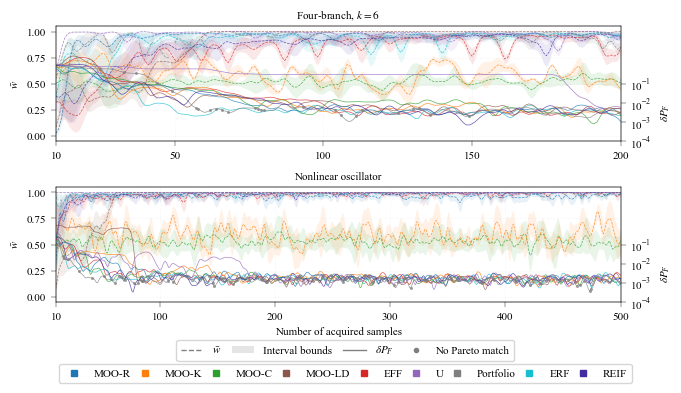

In [27]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
from scipy.ndimage import gaussian_filter1d

# -------------- Configuration & Styling ----------------
doe = 10 
font_size = 8
linewidth = 0.3
sigma = 1.5
cm = 1/2.54 

# Assumed variables for plotting iteration (Exp 1 assumed)
if 'name_exp_to_plot' not in locals() and 'data_by_case' in locals():
    name_exp_to_plot = sorted(list(data_by_case['four_branch_6'].keys()), key=int)
    exp_num_to_use = name_exp_to_plot[0]
    
plt.rcParams.update({
    'font.size': font_size, 'legend.fontsize': font_size, 'legend.title_fontsize': font_size,
    'axes.titlesize': font_size, 'axes.labelsize': font_size,
    'xtick.labelsize': font_size, 'ytick.labelsize': font_size,
    'font.family': 'Times New Roman', 'mathtext.fontset': 'stix',
    'axes.linewidth': linewidth, 'xtick.major.width': linewidth, 'ytick.major.width': linewidth,
    'lines.linewidth': 0.5, 'grid.linewidth': 0.5,
})

strategy_colors = {
    'moo_reliability': "#1f77b4", 'moo_knee': '#ff7f0e', 'moo_compromise': '#2ca02c',
    'moo_eps_ew': '#8c564b', 'erf': '#17becf', 'reif': "#432ca0",
    'eff': '#d62728', 'u': '#9467bd', 'portfolio': '#7f7f7f'
}

strategy_map_filtered = {
    'moo_reliability': r'MOO-R', 'moo_knee': r'MOO-K', 'moo_compromise': r'MOO-C',
    'moo_eps_ew': r'MOO-LD', 'eff': r'EFF', 'u': r'U', 'portfolio': r'Portfolio',
    'erf': r'ERF', 'reif': r'REIF',
}

ordered_strategies = [
    'moo_reliability', 'moo_knee', 'moo_compromise', 'moo_eps_ew',
    'eff', 'u', 'portfolio', 'erf', 'reif'
]

case_map = {
    'four_branch_6': r'Four-branch, $k=6$',
    'nonlinear_oscillator': r'Nonlinear oscillator',
}

max_iterations = {
    'four_branch_6': 200, 
    'nonlinear_oscillator': 500,
}

# -------------- Plotting ----------------

fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(17.5*cm, 10*cm), sharex=False)
case_study_list = ['four_branch_6', 'nonlinear_oscillator']
plotted_strategies_tracker = set()
Y_PAD = 0.05 

for idx, case in enumerate(case_study_list):
    ax = axes[idx]
    ax2 = ax.twinx() 
    
    end_x = max_iterations[case]
    exp_num = str(exp_num_to_use) if 'exp_num_to_use' in locals() else list(data_by_case[case].keys())[0]
    strategies_data = data_by_case[case][exp_num]

    for full_strategy_key, out in strategies_data.items():
        base_strategy = full_strategy_key.split('_')[0]
        if base_strategy == 'moo':
            if full_strategy_key.startswith('moo_reliability'): base_strategy = 'moo_reliability'
            elif full_strategy_key.startswith('moo_knee'): base_strategy = 'moo_knee'
            elif full_strategy_key.startswith('moo_compromise'): base_strategy = 'moo_compromise'
            elif full_strategy_key.startswith('moo_eps_ew'): base_strategy = 'moo_eps_ew'
        
        if base_strategy not in strategy_map_filtered: continue
        line_color = strategy_colors.get(base_strategy, '#000000') 

        # --- 1. Process Weight Intervals & Identify Gaps ---
        valid_mask = None
        if full_strategy_key in interval_mean[case][exp_num]:
            ivals = interval_mean[case][exp_num][full_strategy_key]
            x_vals = np.arange(len(ivals)) + doe
            limit_mask = x_vals <= end_x
            
            mean_vals = np.nanmean(ivals, axis=1)
            valid_mask = ~np.isnan(mean_vals) # True where we HAVE a match
            
            if np.any(valid_mask):
                indices = np.arange(len(mean_vals))
                mean_interp = np.interp(indices, indices[valid_mask], mean_vals[valid_mask])
                mean_gf = gaussian_filter1d(mean_interp, sigma, mode='nearest')
                mean_gf[~valid_mask] = np.nan
                
                ax.plot(x_vals[limit_mask], mean_gf[limit_mask], 
                        linestyle='--', linewidth=0.5, alpha=0.8, color=line_color)
                
                low_interp = np.interp(indices, indices[valid_mask], ivals[valid_mask, 0])
                high_interp = np.interp(indices, indices[valid_mask], ivals[valid_mask, 1])
                l_gf = gaussian_filter1d(low_interp, sigma)
                u_gf = gaussian_filter1d(high_interp, sigma)
                l_gf[~valid_mask], u_gf[~valid_mask] = np.nan, np.nan
                
                ax.fill_between(x_vals[limit_mask], l_gf[limit_mask], u_gf[limit_mask], 
                                color=line_color, alpha=0.1, linewidth=0)

        # --- 2. Plot Delta Pf (Markers on the smoothed line) ---
        if 'Pf_model' in out:
            try: Pf_ref = ls_REGISTRY[case]().target_pf 
            except: Pf_ref = 1e-4
            
            delta_pf = np.abs(np.array(out['Pf_model']) - Pf_ref) / Pf_ref
            x_vals_d = np.arange(len(delta_pf)) + doe
            limit_mask_d = x_vals_d <= end_x
            
            # Smoothing the Pf line
            delta_gf = gaussian_filter1d(delta_pf, sigma, mode='nearest')
            ax2.plot(x_vals_d[limit_mask_d], delta_gf[limit_mask_d], 
                     linestyle='-', linewidth=0.5, alpha=0.8, color=line_color)
            
            # PLACE MARKERS ON THE SMOOTHED LINE
            # We look for iterations where valid_mask is False (No Pareto match)
            if valid_mask is not None:
                # Ensure the mask length matches the plotted delta_gf length
                iter_len = min(len(valid_mask), len(delta_gf), len(limit_mask_d))
                
                # Identify failures within the plot limits
                fail_indices = np.where(~valid_mask[:iter_len] & limit_mask_d[:iter_len])[0]
                
                if len(fail_indices) > 0:
                    ax2.scatter(x_vals_d[fail_indices], delta_gf[fail_indices], 
                                marker='o', color=line_color, s=4, 
                                linewidths=0.1, zorder=10, alpha=0.8)

            if idx == 0: plotted_strategies_tracker.add(base_strategy)

        if idx == 1:
            ax.set_xlabel('Number of acquired samples')

    # --- Formatting Axis ---
    ax.set_ylabel(r'$\bar w$') 
    ax.set_ylim(-Y_PAD, 1 + Y_PAD)
    ax.set_yticks([0, 0.25, 0.5, 0.75, 1.0])
    
    # Lowered Y-label for right axis
    ax2.set_ylabel(r'$\delta P_F$', y=0.25, va='center', labelpad=10) 
    ax2.set_yscale('log')
    ax2.set_ylim(1e-4, 1e2)
    ax2.set_yticks((1e-4, 1e-3, 1e-2, 1e-1))

    ax.set_xlim(doe, end_x)
    if end_x == 200:
        ax.set_xticks([10, 50, 100, 150, 200])
    else:
        ax.set_xticks([10, 100, 200, 300, 400, 500])

    ax.set_title(case_map.get(case, case), pad=5)
    ax.grid(True, linestyle='--', alpha=0.1)

# --- Legend Preparation ---
strat_h = [Line2D([0], [0], marker='s', color=strategy_colors[s], linestyle='', markersize=5) 
           for s in ordered_strategies if s in plotted_strategies_tracker]
strat_l = [strategy_map_filtered[s] for s in ordered_strategies if s in plotted_strategies_tracker]

metric_h = [
    Line2D([0], [0], linestyle='--', color='grey', linewidth=1),
    Patch(facecolor='grey', alpha=0.2, linewidth=0),
    Line2D([0], [0], color='grey', linestyle='-', linewidth=1),
    Line2D([0], [0], marker='o', color='grey', linestyle='', markersize=3)
]
metric_l = [r'$\bar w$', 'Interval bounds', r'$\delta P_F$', 'No Pareto match']


# Legend 1 (Strategies) - Higher
fig.legend(strat_h, strat_l, loc='lower center', ncol=len(strat_h), 
           bbox_to_anchor=(0.5, 0.000), frameon=True, columnspacing=0.2)

# Legend 2 (Metrics) - Lower
fig.legend(metric_h, metric_l, loc='lower center', ncol=4, 
           bbox_to_anchor=(0.5, 0.055), frameon=True, columnspacing=1.0)

for ax in axes.flat:
    ax.tick_params(width=linewidth, which='both')
    for spine in ax.spines.values():
        spine.set_linewidth(linewidth)

plt.subplots_adjust(left=0.08, right=0.9, top=0.92, bottom=0.22, hspace=0.4)
plt.show()

C:\Users\Administrator\AppData\Local\Temp\ipykernel_13928\2291303795.py:51: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('winter_r')
C:\Users\Administrator\AppData\Local\Temp\ipykernel_13928\2291303795.py:118: RuntimeWarning: Mean of empty slice
  means = np.nanmean(weights_dict[full_key], axis=1)


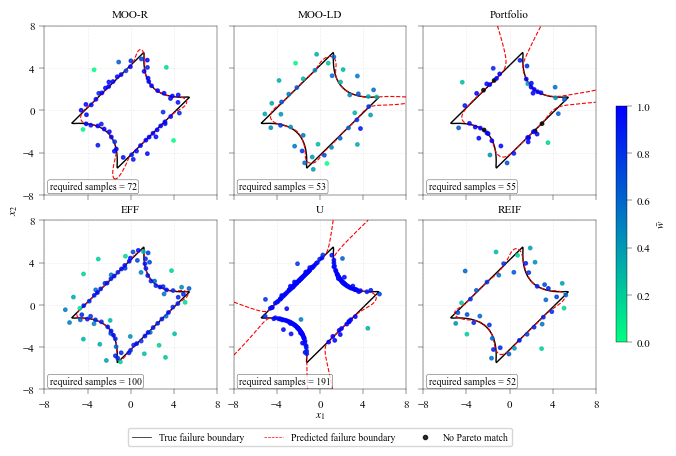

In [169]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.cm as cm
import matplotlib.lines as mlines
import numpy as np
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, ConstantKernel
from utils.data import custom_optimizer, isoprobabilistic_transform

# ── GP KERNEL DEFINITION ──────────────────────────────────────────
def make_base_kernel(input_dim):
    length_init = np.full(input_dim, 1.0, dtype=np.float64)
    kernel = ConstantKernel(1.0, (1e-5, 1e5)) * Matern(
        length_scale=length_init,
        length_scale_bounds=(1e-5, 1e5),
        nu=2.5,
    )
    return kernel

# ── CONFIGURATION & LIMITS ──────────────────────────────────────────
case = 'four_branch_6'
exp_num = str(exp_num_to_use) if 'exp_num_to_use' in locals() else '1'
threshold = 1e-02
# threshold = 5e-03
consecutive_steps = 3
stop_at_convergence = True 
force_max_samples = 190 # Maximum active samples allowed (total 200)

selected_strategies = ['moo_reliability', 'moo_eps_ew', 'portfolio', 'eff', 'u', 'reif']
strategy_map_filtered = {
    'moo_reliability': r'MOO-R', 'moo_eps_ew': r'MOO-LD', 
    'eff': r'EFF', 'u': r'U', 'portfolio': r'Portfolio', 'reif': r'REIF',
}

# ── PREPARE TRUE FAILURE SURFACE ───────────────────────────────────
lstate = ls_REGISTRY[case]()
pf_ref = lstate.target_pf
num_grid = 100
x_lim = 8
x_range = np.linspace(-x_lim, x_lim, num_grid)
X, Y = np.meshgrid(x_range, x_range)
grid_pts = np.stack([X.ravel(), Y.ravel()], axis=1)
g_true = lstate.eval_lstate(grid_pts).reshape(num_grid, num_grid)

# ── PLOTTING SETUP ─────────────────────────────────────────────────
cm_inch = 1/2.54
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(17.5*cm_inch, 12*cm_inch), 
                         sharex=True, sharey=True)
axes_flat = axes.flatten()

cmap = cm.get_cmap('winter_r')
norm_mean = mcolors.Normalize(vmin=0.0, vmax=1.0)
sm_mean = plt.cm.ScalarMappable(cmap=cmap, norm=norm_mean)

for idx, strat_key in enumerate(selected_strategies):
    ax = axes_flat[idx]
    
    # 1) Plot True Failure Boundary
    ax.contour(X, Y, g_true, levels=[0], colors='k', linewidths=1.0, zorder=1)
    
    full_key = next((k for k in data_by_case[case][exp_num].keys() if k.startswith(strat_key)), None)
    
    if full_key:
        out = data_by_case[case][exp_num][full_key]
        samples = np.array(out['training_samples'][0])
        pf_model = np.array(out['Pf_model'])
        
        # --- Convergence Logic ---
        rel_error = np.abs(pf_model - pf_ref) / pf_ref
        conv_idx = None
        for i in range(len(rel_error) - (consecutive_steps - 1)):
            if np.all(rel_error[i : i + consecutive_steps] < threshold):
                conv_idx = i
                break
        
        # Determine number of active samples to plot/use
        # If accuracy reached, we take conv_idx active samples. 
        # Determine number of active samples to use
        if conv_idx is not None and conv_idx <= force_max_samples:
            # If conv_idx is 0, it means the model was accurate with 0 active samples
            n_active_to_plot = conv_idx 
            label_text = f"required samples = {n_active_to_plot + 10}"
        else:
            n_active_to_plot = force_max_samples
            label_text = "required samples > 200"

        # 2) Train GP Surrogate and Plot Boundary
        x_train = samples[:10 + n_active_to_plot]
        y_train = lstate.eval_lstate(x_train)
        
        model_gp = GaussianProcessRegressor(
            kernel=make_base_kernel(lstate.input_dim),
            n_restarts_optimizer=5, 
            optimizer=custom_optimizer,
            normalize_y=True,
            alpha=1e-8
        )
        model_gp.fit(x_train, y_train)
        g_pred = model_gp.predict(grid_pts).reshape(num_grid, num_grid)
        
        ax.contour(X, Y, g_pred, levels=[0], colors='r', linestyles='--', linewidths=0.8, zorder=2)

        # 3) Plot Samples
        # Passive
        # ax.scatter(samples[:10, 0], samples[:10, 1], color='k', s=6, alpha=0.6, zorder=3)
        
        # Active (only up to n_active_to_plot)
        # if full_key in interval_mean[case][exp_num]:
        #     ivals = interval_mean[case][exp_num][full_key]
        #     means = np.nanmean(ivals, axis=1)
        #     active_subset = samples[10 : 10 + n_active_to_plot]
        #     ax.scatter(active_subset[:, 0], active_subset[:, 1], 
        #                c=cmap(norm_mean(means[:n_active_to_plot])), s=6, alpha=0.8, zorder=4)
        active_pts = samples[10 : 10 + n_active_to_plot]
        # Check for weight existence
        weights_dict = interval_mean[case][exp_num]
        if full_key in weights_dict and len(weights_dict[full_key]) > 0:
            means = np.nanmean(weights_dict[full_key], axis=1)
            c_vals = cmap(norm_mean(means[:n_active_to_plot]))
        else:
            c_vals = 'grey' # Portfolio fallback
            
        ax.scatter(active_pts[:,0], active_pts[:,1], c=c_vals, s=6, alpha=0.8, zorder=4)

        # 4) Accuracy Label
        ax.text(0.03, 0.03, label_text, transform=ax.transAxes, fontsize=7,
                bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2', linewidth=0.3))

    # Formatting
    ax.set_title(strategy_map_filtered.get(strat_key, strat_key))
    ax.set_xlim(-x_lim, x_lim); ax.set_ylim(-x_lim, x_lim)
    ax.set_xticks(np.arange(-x_lim, x_lim+2, 4)), ax.set_yticks(np.arange(-x_lim, x_lim+2, 4))
    ax.grid(True, linestyle='--', alpha=0.2)

# ── ADJUSTMENTS ───────────────────────────────────────────────────
plt.subplots_adjust(left=0.08, right=0.88, bottom=0.15, top=0.92, wspace=0.1, hspace=0.150)
cbar_ax = fig.add_axes([0.91, 0.25, 0.015, 0.5])
fig.colorbar(sm_mean, cax=cbar_ax).set_label(r'$\bar{w}$')

fig.text(0.48, 0.09, r'$x_1$', ha='center')
fig.text(0.03, 0.53, r'$x_2$', va='center', rotation='vertical')

# Shared Legend
true_h = mlines.Line2D([], [], color='k', label='True failure boundary')
pred_h = mlines.Line2D([], [], color='r', linestyle='--', label='Predicted failure boundary')
pass_h = mlines.Line2D([], [], color='k', marker='o', linestyle='None', markersize=3, alpha=0.8, label='No Pareto match')

fig.legend(handles=[true_h, pred_h, pass_h], loc='lower center', ncol=3, 
           bbox_to_anchor=(0.48, 0.02), frameon=True, fontsize=7)

plt.show()

In [170]:
fig.savefig(f'four_branch_6_activesamples_evolution.pdf')


--- Convergence Summary for nonlinear_oscillator (Exp 1) ---
Strategy             | Passive  | Active   | Total   
-------------------------------------------------------
moo_reliability      | 10       | 22       | 32      
moo_eps_ew           | 10       | 66       | 76      
portfolio            | 10       | 20       | 30      
eff                  | 10       | 41       | 51      
u                    | 10       | 44       | 54      
reif                 | 10       | 47       | 57      


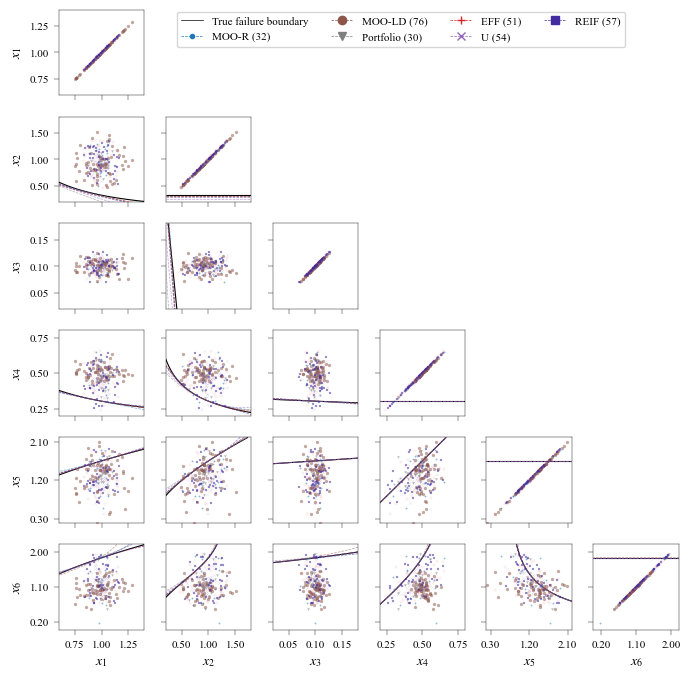

In [165]:
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.lines as mlines
from matplotlib.gridspec import GridSpec
import numpy as np
import matplotlib as mpl
from sklearn.gaussian_process import GaussianProcessRegressor
import matplotlib.ticker as mticker

zoom_limits = {
    'x1': ( 0.60, 1.40),
    'x2': ( 0.20, 1.80),
    'x3': ( 0.02, 0.18),
    'x4': ( 0.20, 0.80),
    'x5': ( 0.20, 2.20),
    'x6': ( 0.00, 2.20),
}
zoom_ticks = {
    'x1': ([0.75, 1.00, 1.25]),
    'x2': ([0.50, 1.00, 1.50]),
    'x3': ([0.05, 0.10, 0.15]),
    'x4': ([0.25, 0.50, 0.75]),
    'x5': ([0.30, 1.20, 2.10]),
    'x6': ([0.20, 1.10, 2.00]),
}
zoom_formats = {
    'x1': '%.2f',
    'x2': '%.2f',
    'x3': '%.2f',
    'x4': '%.2f',
    'x5': '%.2f',
    'x6': '%.2f',
}

# --- 1. SETUP & CONVERGENCE CHECK ---
case = 'nonlinear_oscillator'
exp_num = '1'
threshold = 5e-03
consecutive_steps = 3
force_max_samples = 500

lstate = ls_REGISTRY[case]()
phys_marginals = lstate.physical_marginals
std_marginals = lstate.standard_marginals
variables = list(phys_marginals.keys())
names = [r'$x_1$',r'$x_2$',r'$x_3$',r'$x_4$',r'$x_5$',r'$x_6$']
means = np.array([phys_marginals[v][0] for v in variables])
stds = np.array([phys_marginals[v][1] for v in variables])

selected_strategies = ['moo_reliability', 'moo_eps_ew', 'portfolio', 'eff', 'u', 'reif']
strategy_colors = ['#1f77b4', '#8c564b', '#7f7f7f', '#d62728', '#9467bd', '#432ca0']
strategy_markers = ['.', 'o', 'v', '+', 'x', 's']
strategy_sizes = [5, 5, 3, 10, 5, 3] # Adjusted for visibility

active_phys_list = []
gp_models = []
required_counts = []

print(f"\n--- Convergence Summary for {case} (Exp {exp_num}) ---")
print(f"{'Strategy':<20} | {'Passive':<8} | {'Active':<8} | {'Total':<8}")
print("-" * 55)

for strat_key in selected_strategies:
    available_keys = data_by_case[case][exp_num].keys()
    full_key = next((k for k in available_keys if k.startswith(strat_key)), None)
    
    if full_key:
        out = data_by_case[case][exp_num][full_key]
        raw_samples = np.array(out['training_samples'][0])
        pf_model = np.array(out['Pf_model'])
        
        # Determine Truncation Point
        rel_error = np.abs(pf_model - lstate.target_pf) / lstate.target_pf
        stop_at = force_max_samples
        for i in range(len(rel_error) - (consecutive_steps - 1)):
            if np.all(rel_error[i : i + consecutive_steps] < threshold):
                stop_at = i
                break
        
        # Console Log
        print(f"{strat_key:<20} | {10:<8} | {stop_at:<8} | {10 + stop_at:<8}")
        
        # Transform to physical
        samples_phys = isoprobabilistic_transform(raw_samples, std_marginals, phys_marginals).numpy()
        x_train = samples_phys[:10 + stop_at]
        active_phys_list.append(x_train[10:])
        required_counts.append(10 + stop_at)
        
        # Train GP
        y_train = lstate.eval_lstate(x_train)
        gp = GaussianProcessRegressor(kernel=make_base_kernel(6), n_restarts_optimizer=9, alpha=1e-8, normalize_y=True, optimizer=custom_optimizer)
        gp.fit(x_train, y_train)
        gp_models.append(gp)
    else:
        active_phys_list.append(np.array([]))
        gp_models.append(None)
        required_counts.append(0)

# --- 1. SETUP ---
n = len(names)  # n = 6
num_grid = 100 
fig, axes = plt.subplots(n, n, figsize=(17.5*cm_inch, 17.5*cm_inch))

# Using 0.98 for top/right to eliminate whitespace
plt.subplots_adjust(hspace=0.25, wspace=0.25, top=0.98, bottom=0.08, left=0.08, right=0.98)

for j in range(n): # Row index (y-axis)
    for i in range(n): # Column index (x-axis)
        ax = axes[j, i]
        
        # Now logic includes j == i (the diagonal subplots)
        if j >= i: 
            xi_name, xj_name = variables[i], variables[j]
            xi_lims, xj_lims = zoom_limits[xi_name], zoom_limits[xj_name]
            
            # Grid for Contours
            xi_vec = np.linspace(xi_lims[0], xi_lims[1], num_grid)
            xj_vec = np.linspace(xj_lims[0], xj_lims[1], num_grid)
            Xi, Xj = np.meshgrid(xi_vec, xj_vec)
            
            # 6D pts for evaluation (fixing others to means)
            pts = np.tile(means, (num_grid**2, 1))
            pts[:, i] = Xi.ravel()
            pts[:, j] = Xj.ravel()
            
            # A) True Boundary
            G_true = lstate.eval_lstate(pts).reshape(num_grid, num_grid)
            ax.contour(Xi, Xj, G_true, levels=[0], colors='k', linewidths=0.8, zorder=2)
            
            # B) GP Boundaries & Samples for each strategy
            for s_idx, gp in enumerate(gp_models):
                if gp is not None and len(active_phys_list[s_idx]) > 0:
                    # GP Boundary
                    G_pred = gp.predict(pts).reshape(num_grid, num_grid)
                    ax.contour(Xi, Xj, G_pred, levels=[0], colors=strategy_colors[s_idx], 
                               linestyles='--', linewidths=0.5, alpha=0.6, zorder=3)
                    
                    # Active Samples
                    # For diagonal i==j, these will naturally fall on y=x line
                    ax.scatter(active_phys_list[s_idx][:, i], active_phys_list[s_idx][:, j],
                               color=strategy_colors[s_idx], marker=strategy_markers[s_idx],
                               s=strategy_sizes[s_idx], alpha=0.5, linewidths=0.1, zorder=4)

            # --- Formatting ---
            ax.set_xlim(xi_lims); ax.set_ylim(xj_lims)
            ax.set_xticks(zoom_ticks[xi_name]); ax.set_yticks(zoom_ticks[xj_name])
            ax.xaxis.set_major_formatter(mticker.FormatStrFormatter(zoom_formats[xi_name]))
            ax.yaxis.set_major_formatter(mticker.FormatStrFormatter(zoom_formats[xj_name]))
            
            # Label visibility: Bottom row and Left column
            if j == n-1:
                ax.set_xlabel(names[i], fontsize=10)
            else:
                ax.tick_params(labelbottom=False)
            
            if i == 0:
                ax.set_ylabel(names[j], fontsize=10)
            else:
                ax.tick_params(labelleft=False)

        else:
            # Upper Triangle remains off
            ax.axis('off')

# --- 3. LEGEND (Placed in the empty upper triangle) ---
failure_h = mlines.Line2D([], [], color='k', label='True failure boundary')
strat_handles = [mlines.Line2D([], [], color=strategy_colors[k], marker=strategy_markers[k], 
                                linestyle='--', markersize=6, 
                                label=f"{strategy_map_filtered[selected_strategies[k]]} ({required_counts[k]})") 
                 for k in range(len(selected_strategies))]

fig.legend(handles=[failure_h] + strat_handles, loc='upper right', ncol=4, 
           bbox_to_anchor=(0.91, 0.985), frameon=True, fontsize=8)

plt.show()

In [166]:
fig.savefig(f'activesamples_evolution_nonlinear_oscillator.pdf')

In [14]:
case_it = 'four_branch_6'
exp_it = 'mook_vs_u_eff'
it = 129
Pareto = np.array(data_by_case[case_it][exp_it]['Pareto_metrics'][it][0])
# assume you pick the first (or only) selected sample per iter:
xs, ys = data_by_case[case_it][exp_it]['Pareto_metrics'][it][1][0]
sel_idx, sel_interval = compute_pareto_intervals(Pareto[:,0],
                                            Pareto[:,1],
                                            target=[xs, ys],
                                            res=100_001)

KeyError: 'mook_vs_u_eff'

In [ ]:
case_it = 'four_branch_6'
exp_it = 'mook_vs_u_eff'
for it in range(len(data_by_case[case_it][exp_it]['Pareto_metrics'])):
    if it > 125:
            Pareto = np.array(data_by_case[case_it][exp_it]['Pareto_metrics'][it][0])
            # assume you pick the first (or only) selected sample per iter:
            xs, ys = data_by_case[case_it][exp_it]['Pareto_metrics'][it][1][0]

            # compute_pareto_intervals returns (all_intervals, sel_interval)
            _, sel_interval = compute_pareto_intervals(Pareto[:,0],
                                                       Pareto[:,1],
                                                       target=[xs, ys],
                                                       res=100_001)
        # size = len(data_by_case['four_branch_6']['mook_vs_u_eff']['Pareto_metrics'][it][0])
            print(f'it: {it}, {xs, ys} {sel_interval}')


In [ ]:
name_exp_moo    = ['moor_vs_u_eff', 'mooc_vs_u_eff', 'mook_vs_u_eff']
case_study  = ['four_branch_6', 'nonlinear_oscillator']

Pareto_size = {}
for case in case_study:
    Pareto_size[case] = {}
    for exp in name_exp_moo:
        Pareto_size[case][exp] = []
        iterations = len(data_by_case[case][exp]['Pareto_metrics'])
        for idx in range(iterations):
            Pareto = data_by_case[case][exp]['Pareto_metrics'][idx][0]
            Pareto_size[case][exp].append(len(Pareto))

In [ ]:
# --- styling ---
font_size = 8; linewidth = 0.3; cm = 1/2.54
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'axes.linewidth': linewidth,
    'xtick.major.width': linewidth,
    'ytick.major.width': linewidth,
    'lines.linewidth': 0.5,
    'grid.linewidth': 0.5,
})

fig, ax = plt.subplots(figsize=(10*cm, 7*cm))

# --- lines (no per-line labels; we build legends manually) ---
for case in case_study:
    for exp in name_exp_moo:
        strat = exp.split('_')[0]               # 'moor'|'mooc'|'mook'
        sizes = np.array(Pareto_size[case][exp])
        iters = np.arange(1, len(sizes)+1)
        sm = gaussian_filter1d(sizes, sigma=2, mode='nearest')
        ax.plot(
            iters, sm,
            color=strategy_color[strat],
            linestyle=case_linestyle[case],
            linewidth=1.0,
            alpha=0.9,
        )

ax.set_xlabel(r'Active learning iterations: $t$')
ax.set_ylabel(r'Pareto set size: $K$')
ax.set_yscale('log')
ax.set_xticks(np.arange(0, 191, 25))
ax.set_xlim(0, 190)
ax.set_ylim(5, 1e4)
ax.grid(True, linestyle='--', alpha=0.1)

# --- legend A: strategies (bottom, colored squares) ---
strat_handles = [
    Line2D([0],[0], marker='s', linestyle='', color=strategy_color[k], markersize=6)
    for k in strategy_map_moo
]
strat_labels = [strategy_map_moo[k] for k in strategy_map_moo]

# --- legend B: cases (upper-left, black lines with linestyles) ---
case_handles = [
    Line2D([0],[0], color='black', linestyle=case_linestyle[c], linewidth=1.0)
    for c in case_study
]
case_labels = [case_map[c] for c in case_study]
leg_case = ax.legend(
    case_handles, case_labels,
    loc='upper left',
    frameon=True,
)
leg_case.get_frame().set_linewidth(0.5)

fig.legend(
    strat_handles, strat_labels,
    loc='lower center',
    ncol=len(strat_handles),
    frameon=True,
    bbox_to_anchor=(0.5, 0.07)
)

# --- ensure bottom space for legend ---
fig.subplots_adjust(bottom=0.3)
plt.show()

In [ ]:
N_pool = 1_000_000  # 1e6

# --- styling ---
font_size = 8; linewidth = 0.3; cm = 1/2.54
plt.rcParams.update({
    'font.size': font_size,
    'legend.fontsize': font_size,
    'legend.title_fontsize': font_size,
    'axes.titlesize': font_size,
    'axes.labelsize': font_size,
    'xtick.labelsize': font_size,
    'ytick.labelsize': font_size,
    'font.family': 'Times New Roman',
    'mathtext.fontset': 'stix',
    'axes.linewidth': linewidth,
    'xtick.major.width': linewidth,
    'ytick.major.width': linewidth,
    'lines.linewidth': 0.5,
    'grid.linewidth': 0.5,
})

fig, ax = plt.subplots(figsize=(10*cm, 7*cm))

# --- lines ---
for case in case_study:
    for exp in name_exp_moo:
        strat = exp.split('_')[0]
        sizes = np.array(Pareto_size[case][exp]) / N_pool * 100  # percentage
        iters = np.arange(1, len(sizes)+1)
        sm = gaussian_filter1d(sizes, sigma=2, mode='nearest')
        ax.plot(
            iters, sm,
            color=strategy_color[strat],
            linestyle=case_linestyle[case],
            linewidth=1.0,
            alpha=0.9,
        )

ax.set_xlabel(r'Active learning iterations: $t$')
ax.set_ylabel(r'$K/N_{\mathrm{pool}}$')

# log-scale percentage axis
ax.set_yscale('log')
ax.set_ylim(1e-2, 1)  # from 0.01% up to 100%

# nice log ticks: 100%, 10%, 1%, 0.1%, 0.01%
ax.set_yticks([1e-3, 1e-2, 1e-1, 1])
ax.get_yaxis().set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:g}%"))

ax.set_xticks(np.arange(0, 191, 25))
ax.set_xlim(0, 190)

# --- legend A: strategies (bottom, colored squares) ---
strat_handles = [
    Line2D([0],[0], marker='s', linestyle='', color=strategy_color[k], markersize=6)
    for k in strategy_map_moo
]
strat_labels = [strategy_map_moo[k] for k in strategy_map_moo]

# --- legend B: cases (upper-left, black lines with linestyles) ---
case_handles = [
    Line2D([0],[0], color='black', linestyle=case_linestyle[c], linewidth=1.0)
    for c in case_study
]
case_labels = [case_map[c] for c in case_study]
leg_case = ax.legend(
    case_handles, case_labels,
    loc='upper left',
    frameon=True,
)

fig.legend(
    strat_handles, strat_labels,
    loc='lower center',
    ncol=len(strat_handles),
    frameon=True,
    bbox_to_anchor=(0.5, -0.15)
)

ax.grid(True, which="both", linestyle='--', alpha=0.1)



In [ ]:
fig.savefig(
    'Pareto_size_evolution_moo.pdf',
    bbox_inches='tight'
)